##Step2: Data Collection

###Import necessary libraies

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,VotingClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_curve,roc_auc_score

### Import Dataset

In [ ]:
claimants_data = pd.read_csv("claimants.csv")

##Step 3: Data Understanding

###Perform initial investigation

In [ ]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [ ]:
claimants_data.shape

(1340, 7)

In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,12
CLMINSUR,41
SEATBELT,48
CLMAGE,189
LOSS,0


In [ ]:
claimants_data.dtypes

,0
CASENUM,int64
ATTORNEY,int64
CLMSEX,float64
CLMINSUR,float64
SEATBELT,float64
CLMAGE,float64
LOSS,float64


In [ ]:
claimants_data.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1340.000000,1340.000000,1328.000000,1299.000000,1292.000000,1151.000000,1340.000000
mean,11202.001493,0.488806,0.558735,0.907621,0.017028,28.414422,3.806307
std,9512.750796,0.500061,0.496725,0.289671,0.129425,20.304451,10.636903
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4177.000000,0.000000,0.000000,1.000000,0.000000,9.000000,0.400000
50%,8756.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.069500
75%,15702.500000,1.000000,1.000000,1.000000,0.000000,43.000000,3.781500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


##Step4: Data Preparation

### Removal of null entries

In [ ]:
claimants_data.dropna(inplace=True)

In [ ]:
claimants_data.isna().sum()

,0
CASENUM,0
ATTORNEY,0
CLMSEX,0
CLMINSUR,0
SEATBELT,0
CLMAGE,0
LOSS,0


###Separation of inputs and outputs

In [ ]:
X = claimants_data.drop(labels=["CASENUM",'ATTORNEY'],axis=1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [ ]:
y = claimants_data["ATTORNEY"]
y

,ATTORNEY
0,0
1,1
2,1
3,0
4,1
...,...
1334,1
1336,0
1337,1
1338,0


### Train test split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=13,
    shuffle=True
)

##Step5: Model Building

### Random Forest Initialization

In [ ]:
rf_model = RandomForestClassifier(n_estimators=50,criterion="entropy",max_depth=5)

###GridSearchCV

In [ ]:
grid_search = GridSearchCV(estimator=rf_model,
                           param_grid={"n_estimators":[50,75,100,150],
                                       "max_depth":[5,6,7,8,9],
                                       "criterion":["gini","entropy"]
                                       })
grid_search.fit(X_train,y_train)



{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 50}
0.7249220779220779


In [ ]:
print(grid_search.best_params_)


In [ ]:
print(grid_search.best_score_)

## AdaBoost Initialization

In [ ]:
adaboost_model = AdaBoostClassifier(n_estimators=150)

###GridSearchCV for Adaboost

In [ ]:
grid_search_adaboost = GridSearchCV(
    estimator=adaboost_model,param_grid={'n_estimators':[50,75,100,150]}
)
grid_search_adaboost.fit(X_train,y_train)

GridSearchCV(estimator=AdaBoostClassifier(n_estimators=150),
             param_grid={'n_estimators': [50, 75, 100, 150]})

### Adaboost Score Evaluation

In [ ]:
print(grid_search_adaboost.best_params_)

{'n_estimators': 150}


In [ ]:
print(grid_search_adaboost.best_score_)

0.7249285714285715


### Stacking Initialization

In [ ]:
logistic_model = LogisticRegression()
dt_model = DecisionTreeClassifier()
knn_model= KNeighborsClassifier()

In [ ]:
stacking_technique = VotingClassifier(estimators=
                                      [('log_model',logistic_model),
                                       ('dt_model',dt_model),
                                       ('knn_model',knn_model)])
stacking_technique.fit(X_train,y_train)

VotingClassifier(estimators=[('log_model', LogisticRegression()),
                             ('dt_model', DecisionTreeClassifier()),
                             ('knn_model', KNeighborsClassifier())])

### Step 6: Model Training

In [ ]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=5, n_estimators=50)

### Adboost Model Training

In [ ]:
adaboost_model.fit(X_train,y_train)

AdaBoostClassifier(n_estimators=150)

##Step 7:Model Testing

### Testing for Random forest al

In [ ]:
y_pred_train = rf_model.predict(X_train)

In [ ]:
y_pred_test = rf_model.predict(X_test)

###Testing for Adaboost Algorithm

In [ ]:
y_ada_pred_train = adaboost_model.predict(X_train)

In [ ]:
y_ada_pred_test = adaboost_model.predict(X_test)

###Testing for Stacking Algorithm

In [ ]:
stack_train = stacking_technique.predict(X_train)

In [ ]:
stack_test = stacking_technique.predict(X_test)

##Step 8: Model Evaluation

### Random Forest Evaluation

In [ ]:
print(confusion_matrix(y_train,y_pred_train))

[[356  99]
 [131 290]]


In [ ]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.73      0.78      0.76       455
           1       0.75      0.69      0.72       421

    accuracy                           0.74       876
   macro avg       0.74      0.74      0.74       876
weighted avg       0.74      0.74      0.74       876



0.8346140795071911


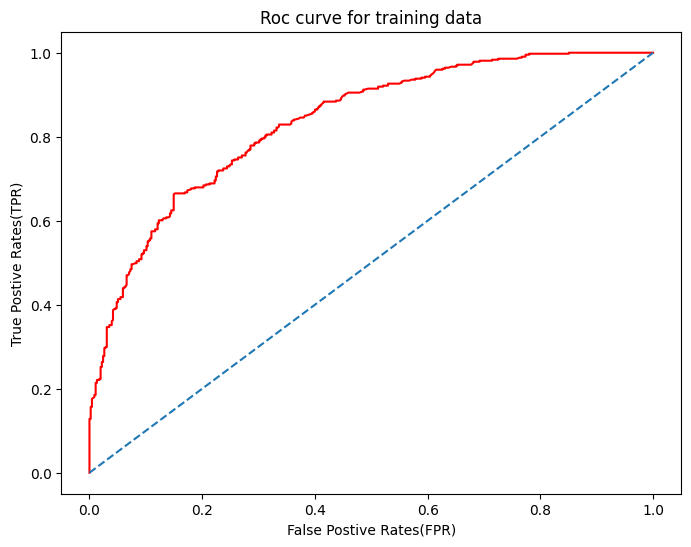

In [ ]:
y_prob = rf_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold = roc_curve(y_train,y_prob)
auc_score = roc_auc_score(
    y_train,
    y_prob
)
print(auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="red")
plt.plot([0,1],[0,1],linestyle="--")
plt.title("Roc curve for training data")
plt.xlabel("False Postive Rates(FPR)")
plt.ylabel("True Postive Rates(TPR)")
plt.show()

In [ ]:
print(confusion_matrix(y_test,y_pred_test))

[[97 26]
 [28 69]]


In [ ]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.78      0.79      0.78       123
           1       0.73      0.71      0.72        97

    accuracy                           0.75       220
   macro avg       0.75      0.75      0.75       220
weighted avg       0.75      0.75      0.75       220



auc_score: 0.7925572039225547


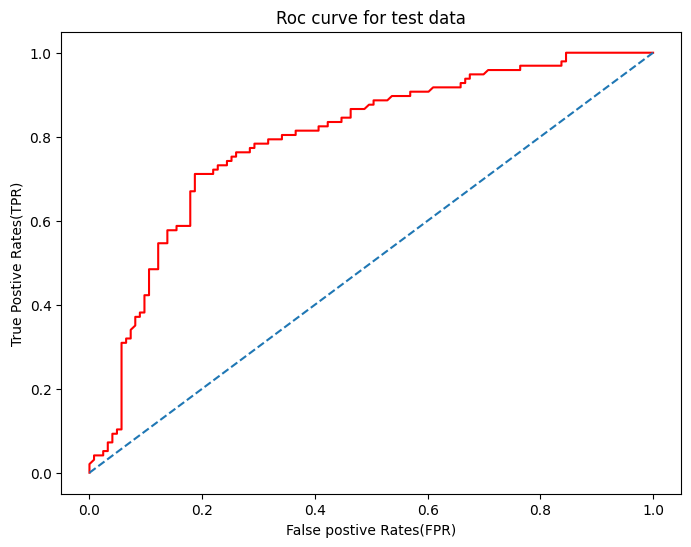

In [ ]:
y_prob = rf_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(
    y_test,
    y_prob
)
auc_score = roc_auc_score(
    y_test,
    y_prob
)
print("auc_score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="red")
plt.plot([0,1],[0,1],linestyle="--")
plt.title("Roc curve for test data")
plt.xlabel("False postive Rates(FPR)")
plt.ylabel("True Postive Rates(TPR)")
plt.show()

### Adaboost Training Evaluation

In [ ]:
print(confusion_matrix(y_train,y_ada_pred_train))

[[347 108]
 [133 288]]


In [ ]:
print(classification_report(y_train,y_ada_pred_train))

              precision    recall  f1-score   support

           0       0.72      0.76      0.74       455
           1       0.73      0.68      0.71       421

    accuracy                           0.72       876
   macro avg       0.73      0.72      0.72       876
weighted avg       0.73      0.72      0.72       876



auc_score: 0.7843752447077863


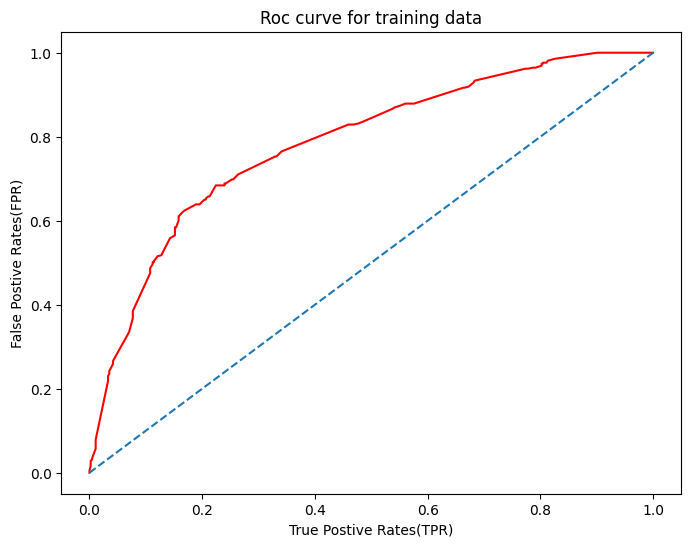

In [ ]:
y_prob = adaboost_model.predict_proba(X_train)[:,1]
fpr,tpr,threshold = roc_curve(y_train,
          y_prob)
auc_score = roc_auc_score(
             y_train,
             y_prob
)
print("auc_score:",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color="red")
plt.plot([0,1],[0,1],linestyle="--")
plt.title("Roc curve for training data")
plt.xlabel("True Postive Rates(TPR)")
plt.ylabel("False Postive Rates(FPR)")
plt.show()

In [ ]:
print(confusion_matrix(y_test,y_ada_pred_test))

[[94 29]
 [28 69]]


In [ ]:
print(classification_report(y_test,y_ada_pred_test))

              precision    recall  f1-score   support

           0       0.77      0.76      0.77       123
           1       0.70      0.71      0.71        97

    accuracy                           0.74       220
   macro avg       0.74      0.74      0.74       220
weighted avg       0.74      0.74      0.74       220



auc_score 0.7970832285642444


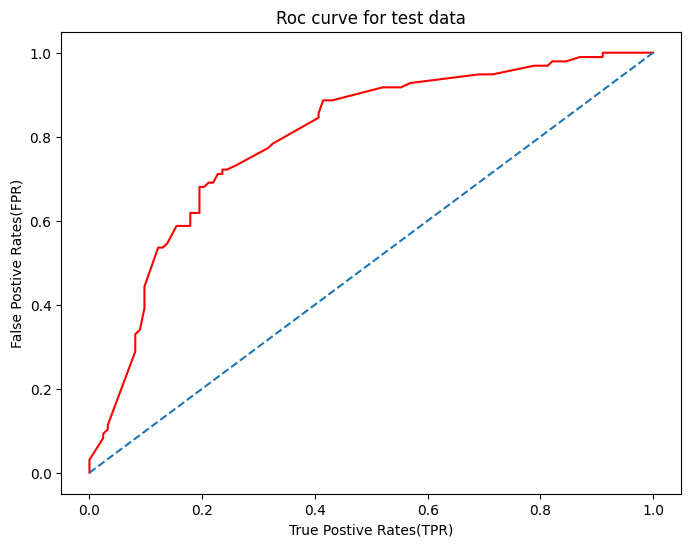

In [ ]:
y_prob = adaboost_model.predict_proba(X_test)[:,1]
fpr,tpr,threshold = roc_curve(y_test,
          y_prob)
auc_score = roc_auc_score(y_test,y_prob)
print("auc_score",auc_score)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,color='red')
plt.plot([0,1],[0,1],linestyle="--")
plt.title("Roc curve for test data")
plt.xlabel("True Postive Rates(TPR)")
plt.ylabel("False Postive Rates(FPR)")
plt.show()

### Stacking Evaluation

In [ ]:
print(confusion_matrix(y_train,stack_train))

[[365  90]
 [ 62 359]]


In [ ]:
print(classification_report(y_train,stack_train))

              precision    recall  f1-score   support

           0       0.85      0.80      0.83       455
           1       0.80      0.85      0.83       421

    accuracy                           0.83       876
   macro avg       0.83      0.83      0.83       876
weighted avg       0.83      0.83      0.83       876



In [ ]:
print(confusion_matrix(y_test,stack_test))

[[82 41]
 [26 71]]


In [ ]:
print(classification_report(y_test,stack_test))

              precision    recall  f1-score   support

           0       0.76      0.67      0.71       123
           1       0.63      0.73      0.68        97

    accuracy                           0.70       220
   macro avg       0.70      0.70      0.69       220
weighted avg       0.70      0.70      0.70       220

